In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

df = pd.read_csv("C:\\Users\\aktiw\\Downloads\\product_reviews_500.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (500, 3)


,Review_ID,Review,Sentiment
0,R001,The product is fair,Neutral
1,R002,Quality is regular for the price,Neutral
2,R003,The product is great and useful,Positive
3,R004,The product is good and useful,Positive
4,R005,hate product and poor service,Negative


In [9]:
print(df["Sentiment"].value_counts())
print("\nPercentage:")
print((df["Sentiment"].value_counts(normalize=True)*100).round(2))

Sentiment
Positive    219
Negative    154
Neutral     127
Name: count, dtype: int64

Percentage:
Sentiment
Positive    43.8
Negative    30.8
Neutral     25.4
Name: proportion, dtype: float64


In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["Clean_Review"] = df["Review"].apply(clean_text)
df[["Review","Clean_Review"]].head()

,Review,Clean_Review
0,The product is fair,the product is fair
1,Quality is regular for the price,quality is regular for the price
2,The product is great and useful,the product is great and useful
3,The product is good and useful,the product is good and useful
4,hate product and poor service,hate product and poor service


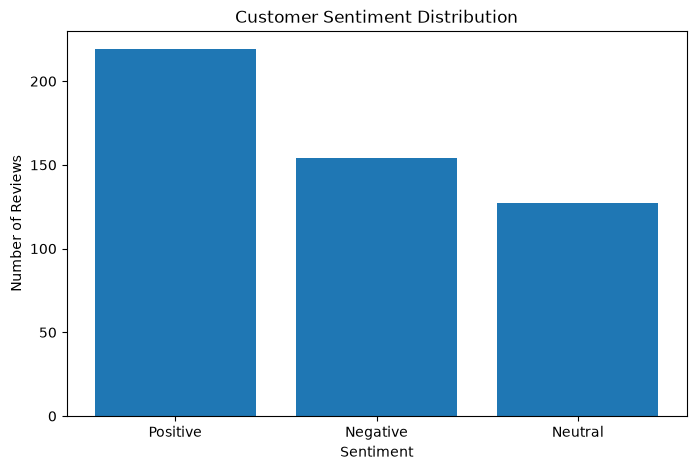

In [11]:
counts=df["Sentiment"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values)
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

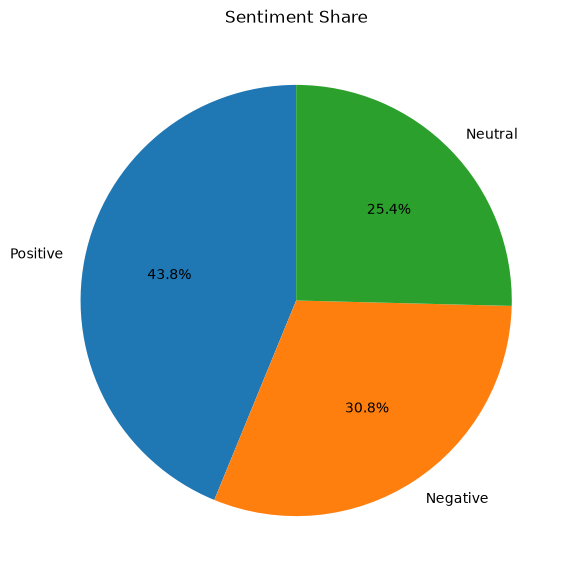

In [12]:
plt.figure(figsize=(7,7))
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Sentiment Share")
plt.show()

,Word,Frequency
0,product,203
1,quality,106
2,delivery,101
3,experience,90
4,service,88
5,excellent,81
6,purchase,77
7,poor,54
8,slow,51
9,disappointing,50


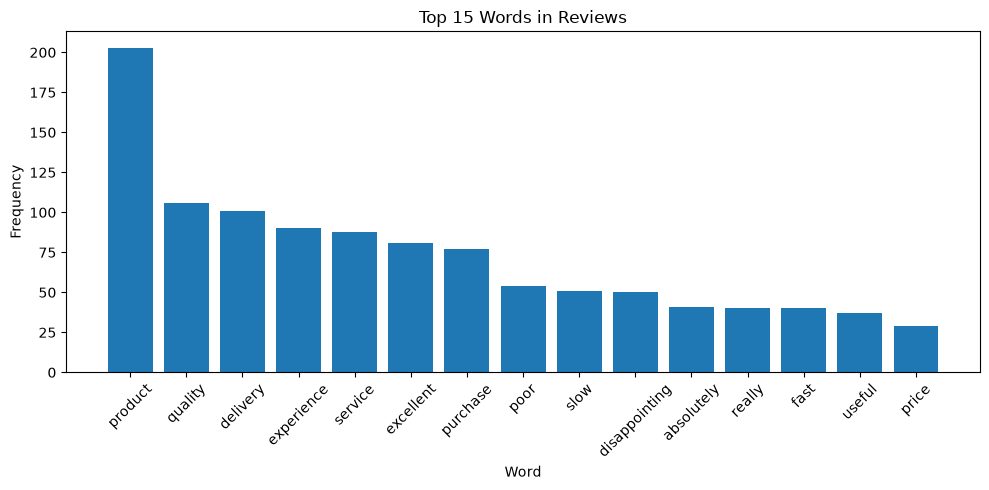

In [13]:
all_words=" ".join(df["Clean_Review"]).split()
stopwords={"the","is","and","a","an","with","this","for","it","i","am","was","to"}
freq=Counter(w for w in all_words if w not in stopwords)

top_words=pd.DataFrame(freq.most_common(15),columns=["Word","Frequency"])
display(top_words)

plt.figure(figsize=(10,5))
plt.bar(top_words["Word"],top_words["Frequency"])
plt.title("Top 15 Words in Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()